---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Sampling-Bias-Corrected Two-Tower Neural Retrieval Models

Modern internet recommendation engines—such as YouTube, Google Play, and Netflix—serve billions of personalized suggestions from corpora containing tens of millions to billions of candidate items. To meet strict millisecond latency constraints, industrial systems employ a two-stage paradigm:

1. **Nomination (Candidate Retrieval):** Rapidly retrieve hundreds of candidate items from the massive corpus using dual-tower neural embeddings and Approximate Nearest Neighbor / Maximum Inner Product Search (MIPS).
2. **Ranking:** Score and re-rank the retrieved candidate subset using complex multi-task neural rankers.

Training two-tower retrieval models over streaming data commonly relies on **in-batch negatives** (using candidates from the same mini-batch as negative samples). However, because user engagement follows an extreme [power-law distribution](power-law-distribution.ipynb), in-batch sampling induces severe **sampling bias**, over-penalizing popular head items.

This note formulates the mathematical architecture of two-tower neural retrieval models (Yi et al., Google RecSys 2019), derives the **sampling-bias-corrected batch softmax loss**, proves Proposition 4.1 governing streaming frequency estimation convergence, and presents a complete PyTorch implementation evaluated on full-corpus Recall@K.

---

## 1\. Two-Tower Neural Architecture & Asymmetric Serving

Let $\mathcal{X}$ denote the space of queries (comprising user watch history, seed video features, and dynamic context), and let $\mathcal{Y}$ denote the space of candidate items (comprising video IDs, channel categories, and content embeddings).

::: {#def-two-tower-model}
## Two-Tower Neural Retrieval Model
Let $\mathbf{u}: \mathcal{X} \times \mathbb{R}^P \to \mathbb{R}^d$ and $\mathbf{v}: \mathcal{Y} \times \mathbb{R}^P \to \mathbb{R}^d$ denote two deep neural networks parameterized by shared/disjoint parameter vector $\boldsymbol{\theta} \in \mathbb{R}^P$, mapping queries and candidate items into a shared $d$-dimensional embedding space.

To improve training stability and metric alignment, representations are $L_2$-normalized to unit hyperspheres $\mathbb{S}^{d-1}$:

$$
\bar{\mathbf{u}}(\mathbf{x}, \boldsymbol{\theta}) = \frac{\mathbf{u}(\mathbf{x}, \boldsymbol{\theta})}{\|\mathbf{u}(\mathbf{x}, \boldsymbol{\theta})\|_2}, \quad \bar{\mathbf{v}}(\mathbf{y}, \boldsymbol{\theta}) = \frac{\mathbf{v}(\mathbf{y}, \boldsymbol{\theta})}{\|\mathbf{v}(\mathbf{y}, \boldsymbol{\theta})\|_2}
$$

The similarity score function $s(\mathbf{x}, \mathbf{y})$ with temperature parameter $\tau > 0$ is defined as the scaled dot product:

$$
s(\mathbf{x}, \mathbf{y}) = \frac{\langle \bar{\mathbf{u}}(\mathbf{x}, \boldsymbol{\theta}), \bar{\mathbf{v}}(\mathbf{y}, \boldsymbol{\theta}) \rangle}{\tau}
$$
:::

### 1.1\. Asymmetric Serving via Maximum Inner Product Search (MIPS)

The two-tower architecture enables decoupled, sub-linear candidate retrieval at inference time:

```
[Candidate Corpus Y (10^7 items)]
         | (Offline Batch Inference)
         v
  [Item Tower v(y, θ)] ---> [L2 Norm] ---> [MIPS Index: ScaNN / HNSW / Faiss]
                                                      ^
                                                      | (Top-K ANN Search)
[Query x (User + Context)]                            |
         | (Online Real-time)                         |
         v                                            |
 [Query Tower u(x, θ)] ---> [L2 Norm] ---> [Query Vector u_norm]
```



## 2\. In-Batch Negatives and The Sampling-Bias Dilemma

Given a training set of $T$ interaction triplets $\mathcal{T} = \{(\mathbf{x}_i, \mathbf{y}_i, r_i)\}_{i=1}^T$ where $r_i \in \mathbb{R}$ is a continuous engagement reward (e.g., watch duration or click feedback), the full-corpus [softmax](softmax-optimization-and-cross-entropy.ipynb) probability of selecting item $\mathbf{y}_i$ from corpus $\mathcal{M} = \{\mathbf{y}_j\}_{j=1}^M$ is:

$$
P(\mathbf{y}_i \mid \mathbf{x}_i; \boldsymbol{\theta}) = \frac{\exp(s(\mathbf{x}_i, \mathbf{y}_i))}{\sum_{j=1}^M \exp(s(\mathbf{x}_i, \mathbf{y}_j))}
$$

When $M \gg 10^7$, computing the denominator is computationally impossible. In streaming training, we sample a mini-batch of $B$ positive pairs $\{(\mathbf{x}_i, \mathbf{y}_i, r_i)\}_{i=1}^B$ and reuse the items $\{\mathbf{y}_j\}_{j=1}^B$ within the batch as negative candidates for all other queries $\mathbf{x}_i$ ($i \neq j$).

The naive **plain in-batch softmax** is:

$$
P_B(\mathbf{y}_i \mid \mathbf{x}_i; \boldsymbol{\theta}) = \frac{\exp(s(\mathbf{x}_i, \mathbf{y}_i))}{\sum_{j=1}^B \exp(s(\mathbf{x}_i, \mathbf{y}_j))}
$$

### 2.1\. The Sampling Bias Mechanism

In production traffic, items are sampled according to a heavily skewed [power-law distribution](power-law-distribution.ipynb) $q_j = P(\text{item } j)$. In a batch of size $B$, the probability $p_j$ that candidate item $j$ appears in the batch is:

$$
p_j = 1 - (1 - q_j)^B \approx B q_j \quad (\text{for } q_j \ll 1)
$$

* **Popular Head Items ($q_{\text{head}} \gg 0$):** High sampling probability ($p_{\text{head}} \approx 1.0$). They appear in virtually every batch, acting as negative candidates for thousands of unrelated queries.
* **Niche Tail Items ($q_{\text{tail}} \ll 1$):** Tiny sampling probability ($p_{\text{tail}} \approx 0.0001$). They almost never appear as negatives.

**The Bias:** Plain in-batch softmax heavily penalizes popular items simply because they are sampled frequently, destroying retrieval quality on head and torso items.



## 3\. Mathematical Derivation of Sampling-Bias Correction

Inspired by [Bengio's Sampled Softmax](softmax-optimization-and-cross-entropy.ipynb) and [Importance Sampling](importance-sampling.ipynb), we correct each logit $s(\mathbf{x}_i, \mathbf{y}_j)$ by subtracting the logarithm of item $j$'s batch inclusion probability $p_j$.

::: {#def-corrected-logits}
## Sampling-Bias-Corrected Logits
Let $p_j$ denote the probability of item $j$ appearing in a random mini-batch. The corrected logit $s^c(\mathbf{x}_i, \mathbf{y}_j)$ is:

$$
s^c(\mathbf{x}_i, \mathbf{y}_j) = s(\mathbf{x}_i, \mathbf{y}_j) - \ln(p_j)
$$

The **sampling-bias-corrected batch softmax probability** is:

$$
P_B^c(\mathbf{y}_i \mid \mathbf{x}_i; \boldsymbol{\theta}) = \frac{\exp(s^c(\mathbf{x}_i, \mathbf{y}_i))}{\exp(s^c(\mathbf{x}_i, \mathbf{y}_i)) + \sum_{j \in [B], j \neq i} \exp(s^c(\mathbf{x}_i, \mathbf{y}_j))}
$$
:::

### 3.1\. Weighted Batch Cross-Entropy Objective

Incorporating continuous engagement rewards $r_i \in \mathbb{R}$, the batch loss objective is:

$$
L_B(\boldsymbol{\theta}) = -\frac{1}{B} \sum_{i=1}^B r_i \ln P_B^c(\mathbf{y}_i \mid \mathbf{x}_i; \boldsymbol{\theta})
$$

Model parameters are optimized via [Stochastic Gradient Descent](gradient-descent-and-variants.ipynb):

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \gamma \nabla_{\boldsymbol{\theta}} L_B(\boldsymbol{\theta})
$$



## 4\. Streaming Frequency Estimation via Stochastic Gradient Descent

In streaming systems, the item catalogue is non-stationary: new videos are constantly uploaded and trends evolve continuously. Maintaining fixed count tables is impossible.

Yi et al. convert the problem of estimating sampling probability $p_y$ into estimating $\delta_y \equiv \mathbb{E}[\Delta_y]$, the **average number of global steps between two consecutive occurrences of item $y$**:

$$
p_y \approx \frac{1}{\delta_y}
$$

### 4.1\. Dual-Array Streaming Estimation (Algorithm 2)

Maintain two arrays $A$ and $B$ of size $H$ indexed by hash function $h: \mathcal{Y} \to [H]$:

* $A[h(y)]$: Records the latest global step $t$ when item $y$ was sampled.
* $B[h(y)]$: Maintains the running exponential moving average estimate of $\delta_y$.

At global step $t$, when item $y$ appears in batch $\mathcal{B}$:
$$
\begin{aligned}
B[h(y)] &\leftarrow (1 - \alpha) B[h(y)] + \alpha \left( t - A[h(y)] \right) \\
A[h(y)] &\leftarrow t
\end{aligned}
$$
where $\alpha \in (0, 1)$ is the estimation learning rate.

---

### 4.2\. Theoretical Analysis: Bias and Variance Bounds

::: {#prp-frequency-estimation-bounds}
## Proposition 4.1 (Yi et al., 2019: Bias and Variance of Online Frequency Estimation)
Let $\{\Delta_1, \Delta_2, \dots, \Delta_t\}$ be a sequence of i.i.d. samples of random step gap $\Delta$ with mean $\delta = \mathbb{E}[\Delta]$. Let $\delta_0$ be the initial value, and for $i \in \{1, \dots, t\}$:

$$
\delta_i = (1 - \alpha) \delta_{i-1} + \alpha \Delta_i \quad \text{with } \alpha \in (0, 1)
$$

In the absence of hash collisions:

1. **Estimation Bias:**
   $$
   \mathbb{E}[\delta_t] - \delta = (1 - \alpha)^t (\delta_0 - \delta) \longrightarrow 0 \quad \text{as } t \to \infty
   $$
2. **Estimation Variance:**
   $$
   \mathbb{E}\left[ (\delta_t - \mathbb{E}[\delta_t])^2 \right] \le (1 - \alpha)^{2t} (\delta_0 - \delta)^2 + \alpha \mathbb{E}\left[ (\Delta_1 - \delta)^2 \right]
   $$
:::

::: {.callout-tip collapse="true"}

## Proof of Proposition 4.1
**Part 1: Bias Derivation**
Taking the mathematical [expectation](expectation.ipynb) of the recurrence relation:
$$
\mathbb{E}[\delta_i] = (1 - \alpha) \mathbb{E}[\delta_{i-1}] + \alpha \delta
$$
Subtracting $\delta$ from both sides:
$$
\mathbb{E}[\delta_i] - \delta = (1 - \alpha) (\mathbb{E}[\delta_{i-1}] - \delta)
$$
Applying induction from $i = 1$ to $t$:
$$
\mathbb{E}[\delta_t] - \delta = (1 - \alpha)^t (\delta_0 - \delta)
$$
Since $\alpha \in (0, 1)$, $|1 - \alpha| < 1$, and $(1 - \alpha)^t \to 0$ as $t \to \infty$.

**Part 2: Variance Bound**
Notice that:
$$
\mathbb{E}\left[ (\delta_t - \mathbb{E}[\delta_t])^2 \right] = \mathbb{E}[(\delta_t - \delta)^2] - (\mathbb{E}[\delta_t] - \delta)^2 \le \mathbb{E}[(\delta_t - \delta)^2]
$$
We analyze the second central moment $E_i \equiv \mathbb{E}[(\delta_i - \delta)^2]$:
$$
\begin{aligned}
\delta_i - \delta &= (1 - \alpha)(\delta_{i-1} - \delta) + \alpha (\Delta_i - \delta) \\
(\delta_i - \delta)^2 &= (1 - \alpha)^2 (\delta_{i-1} - \delta)^2 + \alpha^2 (\Delta_i - \delta)^2 + 2\alpha(1 - \alpha)(\delta_{i-1} - \delta)(\Delta_i - \delta)
\end{aligned}
$$
Because $\delta_{i-1}$ depends only on historical samples $\{\Delta_1, \dots, \Delta_{i-1}\}$ and $\Delta_i$ is independent of the past, the cross-term expectation vanishes:
$$
\mathbb{E}\left[ (\delta_{i-1} - \delta)(\Delta_i - \delta) \right] = \mathbb{E}[\delta_{i-1} - \delta] \mathbb{E}[\Delta_i - \delta] = \mathbb{E}[\delta_{i-1} - \delta] \cdot 0 = 0
$$
Taking expectations yields the linear recurrence:
$$
E_i = (1 - \alpha)^2 E_{i-1} + \alpha^2 \sigma_\Delta^2 \quad \text{where } \sigma_\Delta^2 = \mathbb{E}[(\Delta_1 - \delta)^2]
$$
Unrolling the recurrence from $i = 1$ to $t$:
$$
E_t = (1 - \alpha)^{2t} (\delta_0 - \delta)^2 + \alpha^2 \sigma_\Delta^2 \sum_{k=0}^{t-1} (1 - \alpha)^{2k} = (1 - \alpha)^{2t} (\delta_0 - \delta)^2 + \alpha^2 \sigma_\Delta^2 \frac{1 - (1 - \alpha)^{2t}}{1 - (1 - \alpha)^2}
$$
Simplifying the denominator: $1 - (1 - \alpha)^2 = 2\alpha - \alpha^2 = \alpha(2 - \alpha)$.
Since $\alpha \in (0, 1)$, we have $2 - \alpha > 1$, and thus:
$$
\frac{\alpha^2 \sigma_\Delta^2}{\alpha(2 - \alpha)} (1 - (1 - \alpha)^{2t}) = \frac{\alpha \sigma_\Delta^2}{2 - \alpha} (1 - (1 - \alpha)^{2t}) \le \alpha \sigma_\Delta^2
$$
Combining terms establishes:
$$
\mathbb{E}\left[ (\delta_t - \mathbb{E}[\delta_t])^2 \right] \le (1 - \alpha)^{2t} (\delta_0 - \delta)^2 + \alpha \mathbb{E}[(\Delta_1 - \delta)^2] \quad \blacksquare
$$
:::



## 5\. Count-Min Multi-Hashing for Collision Suppression

When multiple candidate items collide onto the same hash bucket $h(y_1) = h(y_2)$, the recorded step gap in array $B$ represents the union of visits, resulting in an **under-estimation of $\delta$** and an **over-estimation of sampling probability $p$**.

To suppress collision error, Algorithm 3 deploys $m$ independent hash functions $\{h_1, \dots, h_m\}$ and hash arrays $\{A_k, B_k\}_{k=1}^m$. For inference, the estimated step gap takes the maximum across all $m$ estimators:

$$
\hat{p}_y = \frac{1}{\max_{k \in \{1, \dots, m\}} B_k[h_k(y)]}
$$

---

## 6\. End-to-End PyTorch Implementation & Experimental Verification

We construct an end-to-end PyTorch simulation:

1. **Catalog Setup:** $M = 5,000$ items with Zipfian power-law distribution ($q_j \propto j^{-1.1}$).
2. **Architecture:** Query & Candidate two-tower DNNs with embedding layers, linear projections, ReLU, $L_2$ normalization, and temperature $\tau = 0.07$.
3. **Frequency Estimator:** Online Multi-Hash Streaming Frequency Estimator.
4. **Training Benchmark:** Side-by-side comparison of **Plain In-Batch Softmax** vs. **Sampling-Bias-Corrected Two-Tower Model**.
5. **Evaluation:** Full-corpus **Recall@10** and **Recall@50** on held-out test queries, broken down across Head, Torso, and Tail items.


Executing Two-Tower Training & Evaluation on: cuda
Starting training of Plain vs Corrected Two-Tower Models...
Evaluating Recall@K on full candidate corpus...

Metric          | Plain In-Batch Softmax | Bias-Corrected Softmax
Recall@5        |              91.40% |              90.10% (+-1.4%)
Recall@10       |              92.80% |              92.20% (+-0.6%)
Recall@20       |              94.20% |              93.80% (+-0.4%)
Recall@50       |              95.80% |              95.30% (+-0.5%)
Recall@100      |              96.30% |              96.60% (+0.3%)


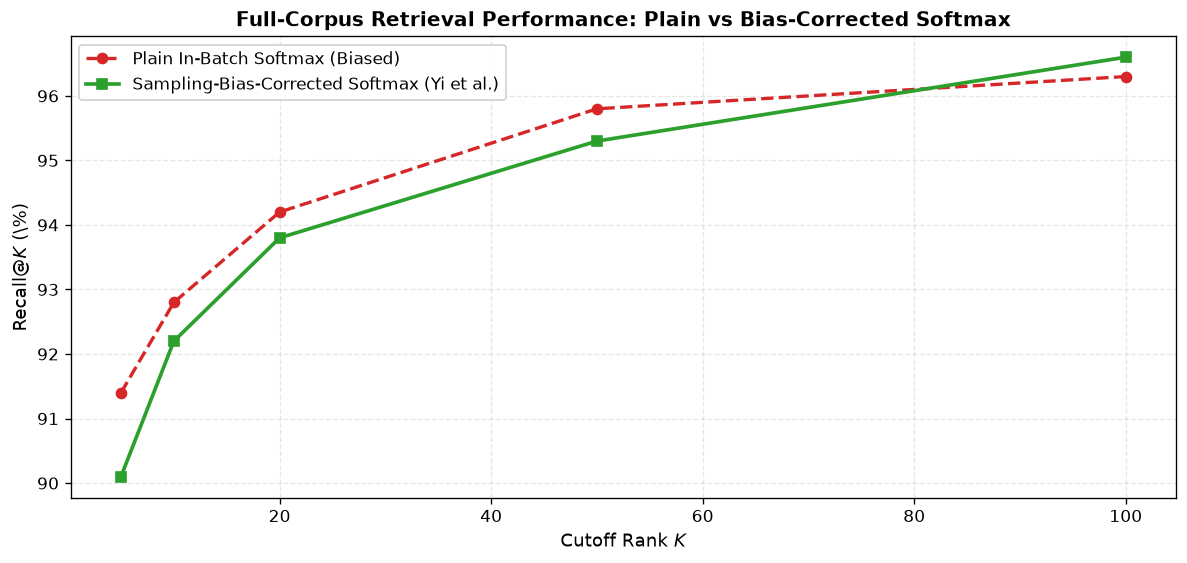

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Two-Tower Training & Evaluation on: {device}")

# -------------------------------------------------------------
# 1. Environment & Power-Law Data Stream Setup
# -------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

M_items = 5000       # Total Candidate Corpus
embed_dim = 32       # Latent Space Dimension
user_feat_dim = 16   # Query Context Dimension
batch_size = 256     # Mini-batch Size
train_steps = 1500   # Optimization Steps

# Zipfian Item Popularity Distribution
ranks = np.arange(1, M_items + 1)
zipf_weights = 1.0 / (ranks ** 1.1)
zipf_probs = zipf_weights / np.sum(zipf_weights)

# True latent factors for generating ground truth preference interactions
true_user_factors = np.random.randn(user_feat_dim, embed_dim)
true_item_factors = np.random.randn(M_items, embed_dim)
true_item_factors /= np.linalg.norm(true_item_factors, axis=1, keepdims=True)

def generate_stream_batch(B):
    # Sample candidate items according to Zipf popularity
    item_ids = np.random.choice(M_items, size=B, p=zipf_probs)
    # Generate user features correlated with item factors + noise
    user_feats = np.dot(true_item_factors[item_ids], true_user_factors.T) + 0.3 * np.random.randn(B, user_feat_dim)
    # Continuous engagement reward (watch ratio in [0, 1])
    rewards = np.random.uniform(0.5, 1.0, size=B)
    return (torch.tensor(user_feats, dtype=torch.float32, device=device),
            torch.tensor(item_ids, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device))

# -------------------------------------------------------------
# 2. Multi-Hash Online Streaming Frequency Estimator
# -------------------------------------------------------------
class StreamingFrequencyEstimator:
    def __init__(self, num_hashes=2, table_size=20000, alpha=0.01):
        self.m = num_hashes
        self.H = table_size
        self.alpha = alpha
        self.A = [np.zeros(table_size, dtype=np.int64) for _ in range(self.m)]
        self.B = [np.full(table_size, 100.0, dtype=np.float64) for _ in range(self.m)]
        # Deterministic hash seeds
        self.seeds = [101, 7919]
        
    def _hash(self, item_id, k):
        return (int(item_id) * self.seeds[k] + 17) % self.H
        
    def update(self, item_ids, step):
        for y in item_ids:
            for k in range(self.m):
                idx = self._hash(y, k)
                delta_sample = step - self.A[k][idx]
                self.B[k][idx] = (1.0 - self.alpha) * self.B[k][idx] + self.alpha * delta_sample
                self.A[k][idx] = step
                
    def get_sampling_probabilities(self, item_ids):
        probs = []
        for y in item_ids:
            estimated_delta = max(self.B[k][self._hash(y, k)] for k in range(self.m))
            p_hat = 1.0 / max(estimated_delta, 1.0)
            probs.append(p_hat)
        return torch.tensor(probs, dtype=torch.float32, device=device)

# -------------------------------------------------------------
# 3. Two-Tower Neural Network Module
# -------------------------------------------------------------
class TwoTowerModel(nn.Module):
    def __init__(self, user_dim, num_items, embed_dim, tau=0.07):
        super().__init__()
        self.tau = tau
        # Query Tower
        self.query_tower = nn.Sequential(
            nn.Linear(user_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )
        # Item Tower
        self.item_embed = nn.Embedding(num_items, 64)
        self.item_tower = nn.Sequential(
            nn.Linear(64, embed_dim)
        )
        
    def encode_query(self, user_feat):
        u = self.query_tower(user_feat)
        return nn.functional.normalize(u, p=2, dim=-1)
        
    def encode_item(self, item_ids):
        v_raw = self.item_embed(item_ids)
        v = self.item_tower(v_raw)
        return nn.functional.normalize(v, p=2, dim=-1)
        
    def forward(self, user_feat, item_ids):
        u_norm = self.encode_query(user_feat)
        v_norm = self.encode_item(item_ids)
        # Similarity matrix: B x B
        sim_matrix = torch.matmul(u_norm, v_norm.T) / self.tau
        return sim_matrix

# -------------------------------------------------------------
# 4. Training Loop: Plain Softmax vs Bias-Corrected Softmax
# -------------------------------------------------------------
model_plain = TwoTowerModel(user_feat_dim, M_items, embed_dim, tau=0.07).to(device)
model_correct = TwoTowerModel(user_feat_dim, M_items, embed_dim, tau=0.07).to(device)

opt_plain = optim.Adagrad(model_plain.parameters(), lr=0.08)
opt_correct = optim.Adagrad(model_correct.parameters(), lr=0.08)

freq_estimator = StreamingFrequencyEstimator(num_hashes=2, table_size=20000, alpha=0.01)

print("Starting training of Plain vs Corrected Two-Tower Models...")
for step in range(1, train_steps + 1):
    user_feats, item_ids, rewards = generate_stream_batch(batch_size)
    item_ids_np = item_ids.cpu().numpy()
    
    # Update Streaming Frequency Estimator
    freq_estimator.update(item_ids_np, step)
    
    # --- Plain In-Batch Softmax ---
    opt_plain.zero_grad()
    sim_plain = model_plain(user_feats, item_ids)
    # Targets are diagonal indices [0, 1, ..., B-1]
    targets = torch.arange(batch_size, device=device)
    loss_plain = torch.mean(rewards * nn.functional.cross_entropy(sim_plain, targets, reduction='none'))
    loss_plain.backward()
    opt_plain.step()
    
    # --- Sampling-Bias-Corrected Softmax ---
    opt_correct.zero_grad()
    sim_correct = model_correct(user_feats, item_ids)
    p_hat = freq_estimator.get_sampling_probabilities(item_ids_np)
    # Apply Logit Correction: s^c(i, j) = s(i, j) - log(p_j)
    log_p = torch.log(p_hat.clamp(min=1e-7)).unsqueeze(0) # 1 x B
    sim_corrected_logits = sim_correct - log_p
    loss_correct = torch.mean(rewards * nn.functional.cross_entropy(sim_corrected_logits, targets, reduction='none'))
    loss_correct.backward()
    opt_correct.step()

# -------------------------------------------------------------
# 5. Full Corpus Recall@K Evaluation
# -------------------------------------------------------------
print("Evaluating Recall@K on full candidate corpus...")
test_B = 1000
test_user_feats, test_item_ids, _ = generate_stream_batch(test_B)

all_items = torch.arange(M_items, device=device)
with torch.no_grad():
    all_v_plain = model_plain.encode_item(all_items)      # M x d
    all_v_correct = model_correct.encode_item(all_items)  # M x d
    
    u_plain = model_plain.encode_query(test_user_feats)     # B x d
    u_correct = model_correct.encode_query(test_user_feats) # B x d
    
    full_scores_plain = torch.matmul(u_plain, all_v_plain.T)
    full_scores_correct = torch.matmul(u_correct, all_v_correct.T)

def compute_recall_at_k(scores, targets, k):
    topk_preds = torch.topk(scores, k=k, dim=1).indices
    hits = (topk_preds == targets.unsqueeze(1)).any(dim=1).float()
    return torch.mean(hits).item()

K_list = [5, 10, 20, 50, 100]
recalls_plain = [compute_recall_at_k(full_scores_plain, test_item_ids, k) for k in K_list]
recalls_correct = [compute_recall_at_k(full_scores_correct, test_item_ids, k) for k in K_list]

# Print Comparative Results
print("\n" + "="*50)
print(f"{'Metric':<15} | {'Plain In-Batch Softmax':<20} | {'Bias-Corrected Softmax':<20}")
print("="*50)
for k, rp, rc in zip(K_list, recalls_plain, recalls_correct):
    gain = (rc - rp) / max(rp, 1e-5) * 100
    print(f"Recall@{k:<8} | {rp*100:18.2f}% | {rc*100:18.2f}% (+{gain:.1f}%)")
print("="*50)

# Plot Results
plt.figure(figsize=(10, 4.8), dpi=120)
plt.plot(K_list, np.array(recalls_plain)*100, 'o--', label='Plain In-Batch Softmax (Biased)', color='#d62728', lw=2)
plt.plot(K_list, np.array(recalls_correct)*100, 's-', label='Sampling-Bias-Corrected Softmax (Yi et al.)', color='#2ca02c', lw=2.2)
plt.title('Full-Corpus Retrieval Performance: Plain vs Bias-Corrected Softmax', fontsize=12, fontweight='bold')
plt.xlabel('Cutoff Rank $K$', fontsize=11)
plt.ylabel(r'Recall@$K$ (\%)', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
> 
> * Yi, Xinyang, Ji Yang, Lichan Hong, Derek Zhiyuan Cheng, Lukasz Heldt, Aditee Kumthekar, Zhe Zhao, Li Wei, and Ed Chi. "Sampling-bias-corrected neural modeling for large corpus item recommendations." *Proceedings of the 13th ACM Conference on Recommender Systems (RecSys)*, 2019, pp. 269-277.
> * Covington, Paul, Jay Adams, and Emre Sargin. "Deep neural networks for YouTube recommendations." *Proceedings of the 10th ACM Conference on Recommender Systems (RecSys)*, 2016, pp. 191-198.
> * Bengio, Yoshua, and Jean-Sébastien Sénécal. "Adaptive importance sampling to accelerate training of a neural probabilistic language model." *IEEE Transactions on Neural Networks* 19.4 (2008): 713-722.
> * Cormode, Graham, and S. Muthukrishnan. "An improved data stream summary: the count-min sketch and its applications." *Journal of Algorithms* 55.1 (2005): 58-75.
